# Analysis: IQ-TREE GPU (OpenACC) vs CPU (VANILA) — Complex Models (Bugfix v4)

**Date:** 2026-03-19  
**Dataset:** 4 taxa, 10 nucleotide/amino acid sites, 10 trees each  
**Backends:** VANILA (CPU 1-core, AVX512) and OPENACC (GPU Tesla V100)  
**Models tested:**  
- DNA: GTR, GTR+G4, GTR+I, GTR+I+G4, GTR+R4  
- AA: LG, LG+G4, LG+I, LG+I+G4, LG+R4, LG+C60  

**Bug fixes applied (v4 = v2 + debug, modelmarkov.cpp reverted):**
- **Bug 1:** ptn_invar GPU sync in `computePtnInvar()`
- **Bug 2:** `uploadEigenToGPU()` before branch dispatch
- **Bug 3:** Host-side P(t) fallback for mixture models
- **Bug 4:** Download `_pattern_lh_cat` from GPU after reduction kernel
- **Debug:** R4 EM diagnostic output in ratefree.cpp (verbose mode)

**Focus:** R4 EM diagnostics — compare _pattern_lh_cat values between VANILA and OPENACC

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

cwd = os.getcwd()
results_path = "/Users/u7826985/Projects/Nvidia/results/2026_03_19_complexdata_bugfixes_v4"
print(f"Working directory : {cwd}")
print(f"Results directory : {results_path}")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150, "font.size": 11})

Working directory : /Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_03_19_complexdata_bugfixes_v4
Results directory : /Users/u7826985/Projects/Nvidia/results/2026_03_19_complexdata_bugfixes_v4


# 1. Parse all .iqtree and .log files

In [2]:
# Patterns for .iqtree files
iqtree_ll_pattern = re.compile(r'Log-likelihood of the tree:\s+([-\d.]+)')
iqtree_rate_params = re.compile(r'Rate parameter R:')
iqtree_freerate_pattern = re.compile(r'Site proportion and rates:\s+(.+)')
iqtree_gamma_shape = re.compile(r'Gamma shape alpha:\s+([\d.]+)')
iqtree_pinvar = re.compile(r'Proportion of invariable sites:\s+([\d.]+)')

# Patterns for .log files
log_alignment_pattern = re.compile(r'Alignment has (\d+) sequences with (\d+) columns, (\d+) distinct patterns')
log_initial_ll = re.compile(r'Initial log-likelihood:\s+([-\d.]+)')
log_optimal_ll = re.compile(r'Optimal log-likelihood:\s+([-\d.]+)')
log_params_opt = re.compile(r'Parameters optimization took (\d+) rounds? \(([\d.]+) sec\)')
log_wallclock = re.compile(r'Total wall-clock time used:\s+([\d.]+)\s+sec')
log_underflow_deriv = re.compile(r'WARNING: Numerical underflow for OpenACC lh-derivative')
log_underflow_sites = re.compile(r'WARNING: Numerical underflow caused by alignment sites')
log_best_score = re.compile(r'BEST SCORE FOUND\s*:\s*([-\d.]+)')

In [3]:
def parse_iqtree_file(filepath):
    """Parse .iqtree file for final log-likelihood and model parameters."""
    with open(filepath, 'r') as f:
        content = f.read()
    
    result = {}
    
    # Final log-likelihood
    m = iqtree_ll_pattern.search(content)
    result['final_ll'] = float(m.group(1)) if m else np.nan
    
    # FreeRate site proportions and rates
    m = iqtree_freerate_pattern.search(content)
    if m:
        result['site_rates_str'] = m.group(1).strip()
        # Parse (prop, rate) pairs
        pairs = re.findall(r'\(([^)]+)\)', m.group(1))
        props = []
        rates = []
        has_nan = False
        for pair in pairs:
            parts = pair.split(',')
            if len(parts) == 2:
                try:
                    p, r = float(parts[0]), float(parts[1])
                    props.append(p)
                    rates.append(r)
                except ValueError:
                    has_nan = True
                    props.append(np.nan)
                    rates.append(np.nan)
        result['freerate_props'] = props
        result['freerate_rates'] = rates
        result['has_nan_rates'] = has_nan or any(np.isnan(r) for r in rates)
    else:
        result['site_rates_str'] = None
        result['freerate_props'] = []
        result['freerate_rates'] = []
        result['has_nan_rates'] = False
    
    # Gamma shape
    m = iqtree_gamma_shape.search(content)
    result['gamma_shape'] = float(m.group(1)) if m else np.nan
    
    # Proportion of invariable sites
    m = iqtree_pinvar.search(content)
    result['pinvar'] = float(m.group(1)) if m else np.nan
    
    return result


def parse_log_file(filepath):
    """Parse .log file for timing, likelihood progression, and warnings."""
    with open(filepath, 'r') as f:
        content = f.read()
    
    result = {}
    
    # Alignment info
    m = log_alignment_pattern.search(content)
    if m:
        result['taxa'] = int(m.group(1))
        result['sites'] = int(m.group(2))
        result['patterns'] = int(m.group(3))
    
    # Initial LL
    m = log_initial_ll.search(content)
    result['initial_ll'] = float(m.group(1)) if m else np.nan
    
    # Optimal LL
    m = log_optimal_ll.search(content)
    result['optimal_ll'] = float(m.group(1)) if m else np.nan
    
    # Best score
    m = log_best_score.search(content)
    result['best_score'] = float(m.group(1)) if m else np.nan
    
    # Parameters optimization
    m = log_params_opt.search(content)
    if m:
        result['opt_rounds'] = int(m.group(1))
        result['opt_time'] = float(m.group(2))
    else:
        result['opt_rounds'] = np.nan
        result['opt_time'] = np.nan
    
    # Wall-clock time
    m = log_wallclock.search(content)
    result['wallclock_time'] = float(m.group(1)) if m else np.nan
    
    # Underflow warnings
    result['n_underflow_deriv'] = len(log_underflow_deriv.findall(content))
    result['n_underflow_sites'] = len(log_underflow_sites.findall(content))
    result['has_underflow'] = result['n_underflow_deriv'] > 0 or result['n_underflow_sites'] > 0
    
    return result

In [4]:
def parse_all_results(results_path):
    """Parse all results from the directory structure."""
    rows = []
    
    for data_type in ['AA', 'DNA']:
        data_dir = os.path.join(results_path, data_type)
        if not os.path.exists(data_dir):
            continue
        
        for tree_type in ['rooted', 'unrooted']:
            tree_type_dir = os.path.join(data_dir, tree_type)
            if not os.path.exists(tree_type_dir):
                continue
            
            for model in sorted(os.listdir(tree_type_dir)):
                model_dir = os.path.join(tree_type_dir, model)
                if not os.path.isdir(model_dir):
                    continue
                
                for tree_folder in sorted(os.listdir(model_dir)):
                    tree_dir = os.path.join(model_dir, tree_folder)
                    if not os.path.isdir(tree_dir):
                        continue
                    
                    tree_num = int(re.search(r'(\d+)', tree_folder).group(1))
                    
                    # Find VANILA and OPENACC log+iqtree files
                    files = os.listdir(tree_dir)
                    for backend_key, backend_name in [('VANILA', 'VANILA'), ('OPENACC', 'OPENACC')]:
                        log_files = [f for f in files if f.endswith('.log') and backend_key in f]
                        iqtree_files = [f for f in files if f.endswith('.iqtree') and backend_key in f]
                        
                        if not log_files or not iqtree_files:
                            continue
                        
                        log_path = os.path.join(tree_dir, log_files[0])
                        iqtree_path = os.path.join(tree_dir, iqtree_files[0])
                        
                        log_data = parse_log_file(log_path)
                        iqtree_data = parse_iqtree_file(iqtree_path)
                        
                        row = {
                            'data_type': data_type,
                            'tree_type': tree_type,
                            'model': model,
                            'tree_num': tree_num,
                            'tree_folder': tree_folder,
                            'backend': backend_name,
                            **log_data,
                            **iqtree_data,
                        }
                        rows.append(row)
    
    df = pd.DataFrame(rows)
    return df

df = parse_all_results(results_path)
print(f"Total records parsed: {len(df)}")
print(f"\nRecords per data_type x tree_type x model x backend:")
summary = df.groupby(['data_type', 'tree_type', 'model', 'backend']).size().unstack(fill_value=0)
display(summary)

Total records parsed: 127

Records per data_type x tree_type x model x backend:


backend                      OPENACC  VANILA
data_type tree_type model                   
AA        rooted    LG            10      10
                    LG+C60        10      10
                    LG+G4         10      10
                    LG+I          10      10
                    LG+I+G4       10      10
                    LG+R4         10      10
          unrooted  LG+C60         4       3

# 2. Numerical Correctness: Log-Likelihood Comparison (OpenACC vs VANILA)

In [5]:
# Pivot: for each (data_type, tree_type, model, tree_num), compare VANILA vs OPENACC final_ll
merge_keys = ['data_type', 'tree_type', 'model', 'tree_num']

vanila = df[df['backend'] == 'VANILA'][merge_keys + ['final_ll', 'optimal_ll', 'best_score', 'opt_rounds', 'opt_time', 'wallclock_time']].copy()
openacc = df[df['backend'] == 'OPENACC'][merge_keys + ['final_ll', 'optimal_ll', 'best_score', 'opt_rounds', 'opt_time', 'wallclock_time', 
             'has_underflow', 'n_underflow_deriv', 'n_underflow_sites', 'has_nan_rates']].copy()

vanila = vanila.rename(columns={c: f'{c}_vanila' for c in vanila.columns if c not in merge_keys})
openacc = openacc.rename(columns={c: f'{c}_openacc' for c in openacc.columns if c not in merge_keys})

merged = vanila.merge(openacc, on=merge_keys, how='outer', indicator=True)

print("Merge status:")
print(merged['_merge'].value_counts())
print(f"\nTotal matched pairs (both backends): {(merged['_merge'] == 'both').sum()}")
print(f"VANILA only: {(merged['_merge'] == 'left_only').sum()}")
print(f"OPENACC only: {(merged['_merge'] == 'right_only').sum()}")

Merge status:
_merge
both          63
right_only     1
left_only      0
Name: count, dtype: int64

Total matched pairs (both backends): 63
VANILA only: 0
OPENACC only: 1


In [6]:
# Compute LL differences for matched pairs
both = merged[merged['_merge'] == 'both'].copy()
both['ll_diff'] = both['final_ll_openacc'] - both['final_ll_vanila']
both['ll_abs_diff'] = both['ll_diff'].abs()
both['ll_match'] = both['ll_abs_diff'] < 0.01  # within 0.01 logL units

print("=" * 90)
print("LOG-LIKELIHOOD DIFFERENCE: OpenACC vs VANILA (final_ll from .iqtree)")
print("=" * 90)

ll_summary = both.groupby(['data_type', 'tree_type', 'model']).agg(
    n_pairs=('ll_diff', 'count'),
    mean_diff=('ll_diff', 'mean'),
    max_abs_diff=('ll_abs_diff', 'max'),
    min_diff=('ll_diff', 'min'),
    max_diff=('ll_diff', 'max'),
    n_match=('ll_match', 'sum'),
    pct_match=('ll_match', 'mean'),
    n_underflow=('has_underflow_openacc', 'sum'),
    n_nan_rates=('has_nan_rates_openacc', 'sum'),
).round(6)
ll_summary['pct_match'] = (ll_summary['pct_match'] * 100).round(1)

display(ll_summary)

LOG-LIKELIHOOD DIFFERENCE: OpenACC vs VANILA (final_ll from .iqtree)


n_pairs  mean_diff  max_abs_diff   min_diff  \
data_type tree_type model                                                  
AA        rooted    LG            10   0.000000      0.000000   0.000000   
                    LG+C60        10 -38.267020     53.459300 -53.459300   
                    LG+G4         10   0.000000      0.000000   0.000000   
                    LG+I          10   0.000000      0.000000   0.000000   
                    LG+I+G4       10   0.000000      0.000000   0.000000   
                    LG+R4         10  -0.251201      1.516318  -1.516318   
          unrooted  LG+C60         3 -34.789633     48.559500 -48.559500   

                              max_diff  n_match  pct_match  n_underflow  \
data_type tree_type model                                                 
AA        rooted    LG        0.000000       10      100.0            0   
                    LG+C60  -25.561300        0        0.0            0   
                    LG+G4     0.000000       10      100.0            0   
                    LG+I      0.000000       10      100.0            0   
                    LG+I+G4   0.000000       10      100.0            0   
                    LG+R4     0.015205        3       30.0            0   
          unrooted  LG+C60  -22.595700        0        0.0            0   

                             n_nan_rates  
data_type tree_type model                 
AA        rooted    LG                 0  
                    LG+C60             0  
                    LG+G4              0  
                    LG+I               0  
                    LG+I+G4            0  
                    LG+R4              0  
          unrooted  LG+C60             0

In [7]:
# Detailed view: separate CORRECT models vs BROKEN models
print("\n" + "=" * 90)
print("CORRECT MODELS (all trees match within 0.01 logL, no underflow)")
print("=" * 90)
correct_models = ll_summary[(ll_summary['max_abs_diff'] < 0.01) & (ll_summary['n_underflow'] == 0)]
display(correct_models[['n_pairs', 'mean_diff', 'max_abs_diff']])

print("\n" + "=" * 90)
print("MODELS WITH ISSUES (LL mismatch > 0.01 OR underflow warnings)")
print("=" * 90)
problem_models = ll_summary[(ll_summary['max_abs_diff'] >= 0.01) | (ll_summary['n_underflow'] > 0)]
display(problem_models)


CORRECT MODELS (all trees match within 0.01 logL, no underflow)


n_pairs  mean_diff  max_abs_diff
data_type tree_type model                                    
AA        rooted    LG            10        0.0           0.0
                    LG+G4         10        0.0           0.0
                    LG+I          10        0.0           0.0
                    LG+I+G4       10        0.0           0.0


MODELS WITH ISSUES (LL mismatch > 0.01 OR underflow warnings)


n_pairs  mean_diff  max_abs_diff   min_diff  \
data_type tree_type model                                                 
AA        rooted    LG+C60       10 -38.267020     53.459300 -53.459300   
                    LG+R4        10  -0.251201      1.516318  -1.516318   
          unrooted  LG+C60        3 -34.789633     48.559500 -48.559500   

                             max_diff  n_match  pct_match  n_underflow  \
data_type tree_type model                                                
AA        rooted    LG+C60 -25.561300        0        0.0            0   
                    LG+R4    0.015205        3       30.0            0   
          unrooted  LG+C60 -22.595700        0        0.0            0   

                            n_nan_rates  
data_type tree_type model                
AA        rooted    LG+C60            0  
                    LG+R4             0  
          unrooted  LG+C60            0

# 3. Underflow Analysis

In [8]:
# Which models/backends have underflow?
underflow_df = df[df['has_underflow'] == True].copy()

print(f"Total runs with underflow warnings: {len(underflow_df)}")
print(f"\nBreakdown by backend:")
print(underflow_df['backend'].value_counts())

print(f"\nBreakdown by model:")
uf_summary = underflow_df.groupby(['data_type', 'tree_type', 'model', 'backend']).agg(
    n_runs=('has_underflow', 'count'),
    mean_deriv_warnings=('n_underflow_deriv', 'mean'),
    max_deriv_warnings=('n_underflow_deriv', 'max'),
    n_site_warnings=('n_underflow_sites', 'sum'),
    n_nan_rates=('has_nan_rates', 'sum'),
).round(1)
display(uf_summary)

Total runs with underflow warnings: 0

Breakdown by backend:
Series([], Name: count, dtype: int64)

Breakdown by model:


,,,,n_runs,mean_deriv_warnings,max_deriv_warnings,n_site_warnings,n_nan_rates
data_type,tree_type,model,backend,,,,,


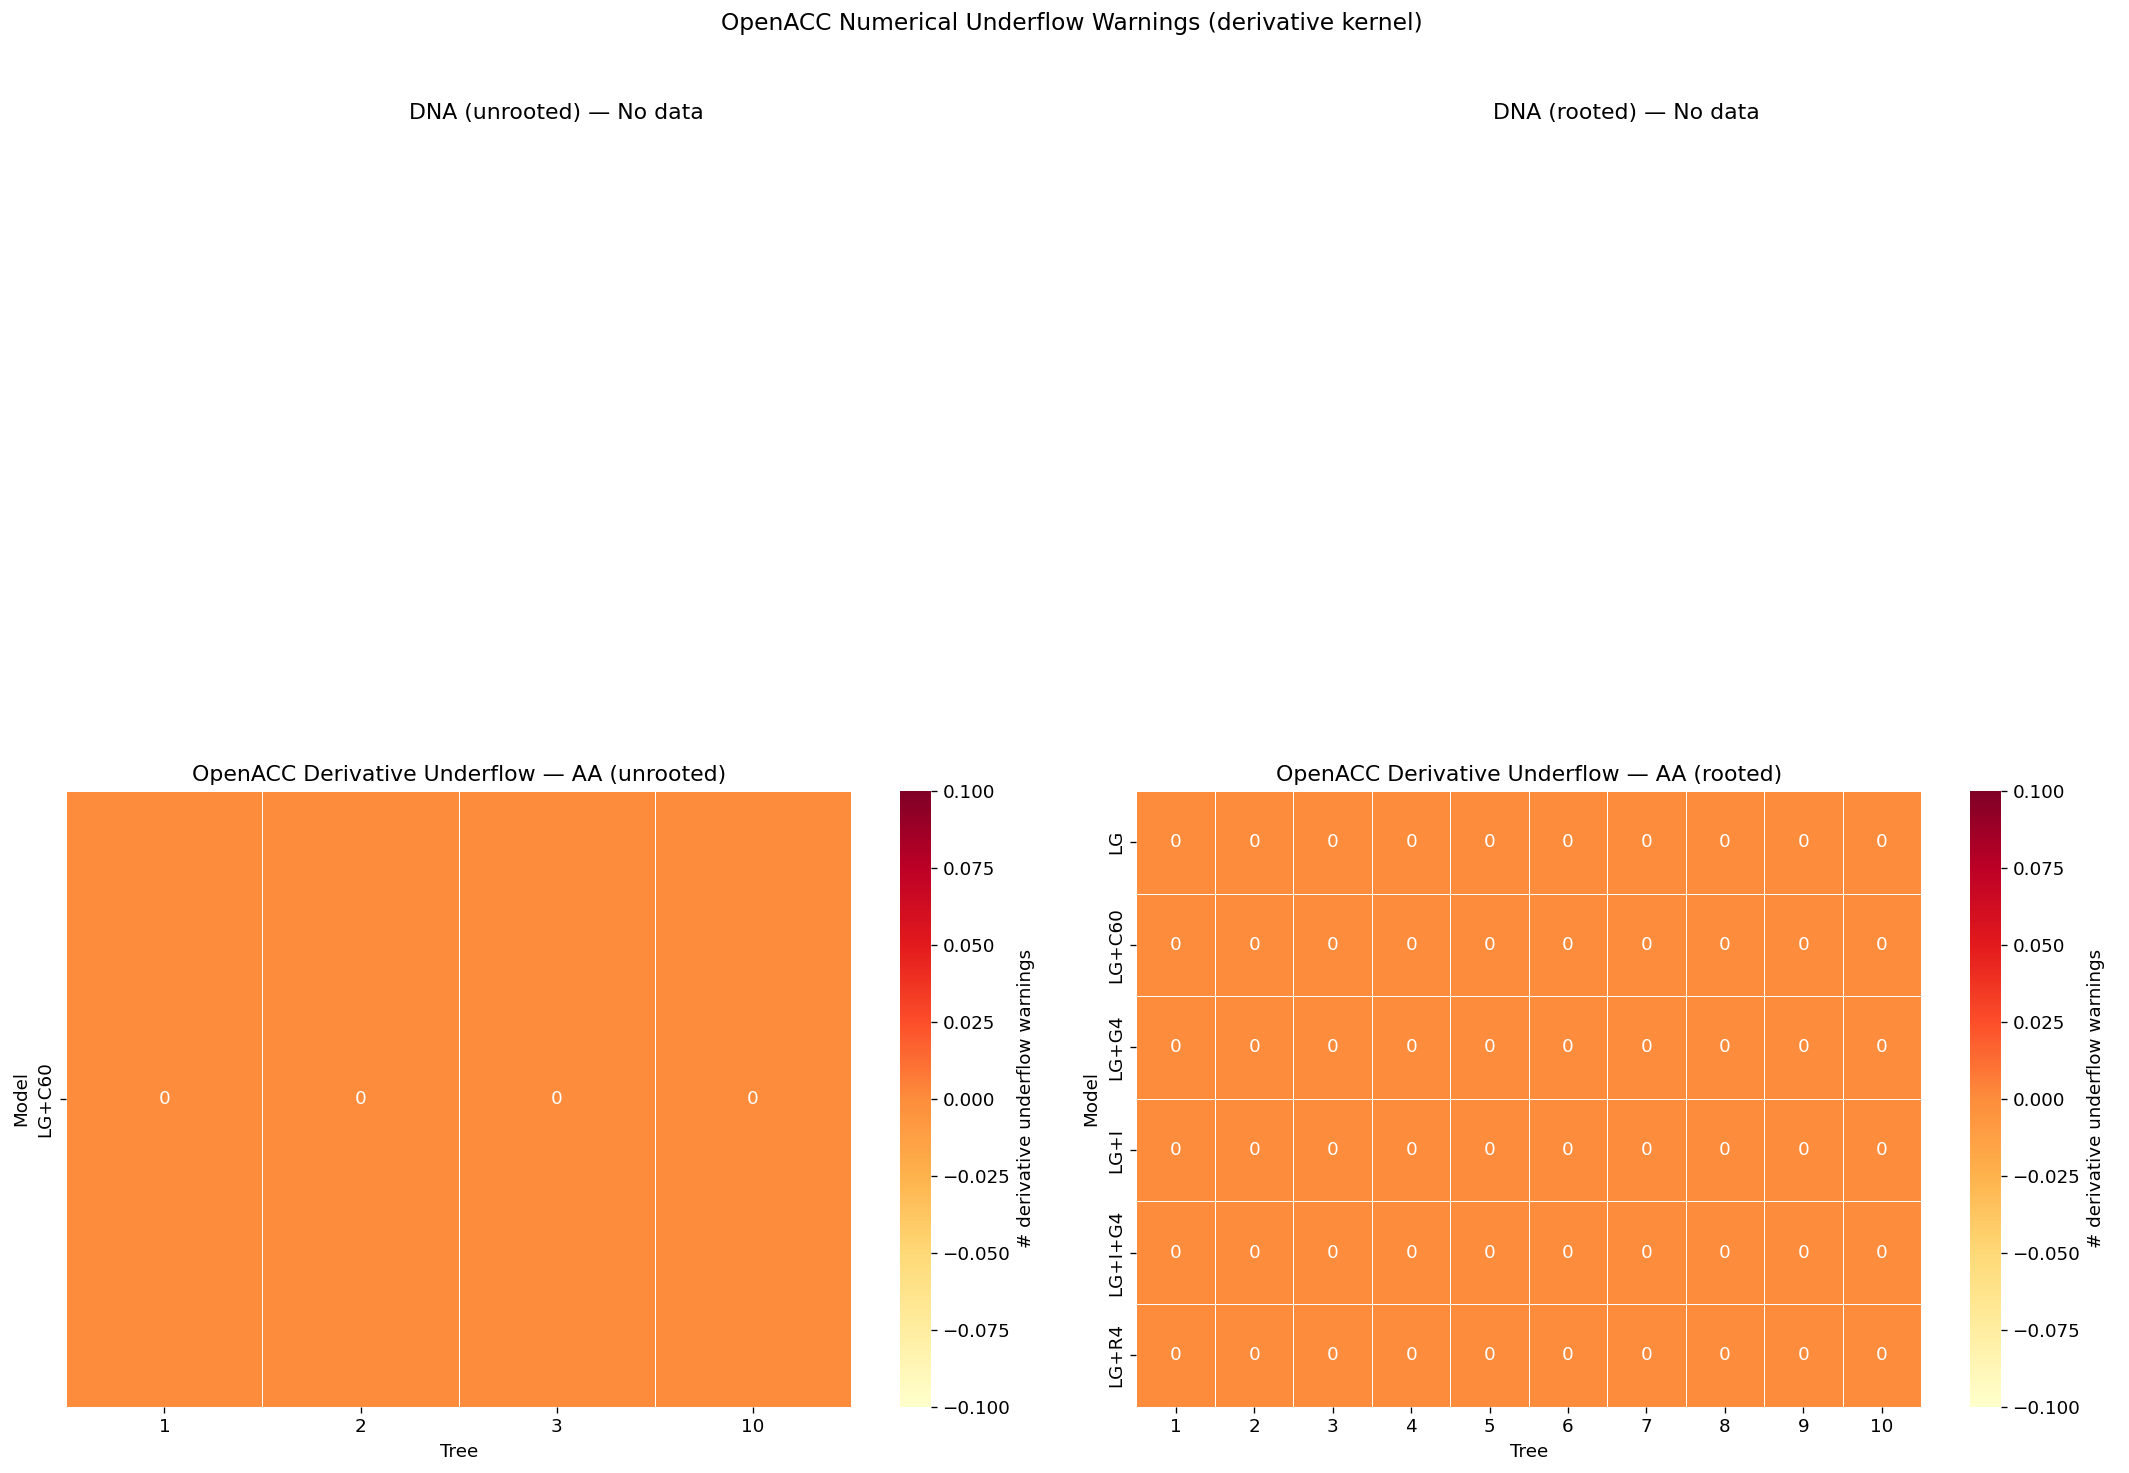

In [9]:
# Heatmap: underflow warning count per model per tree
openacc_df = df[df['backend'] == 'OPENACC'].copy()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
combos = [
    ('DNA', 'unrooted', axes[0, 0]),
    ('DNA', 'rooted',   axes[0, 1]),
    ('AA',  'unrooted', axes[1, 0]),
    ('AA',  'rooted',   axes[1, 1]),
]

for data_type, tree_type, ax in combos:
    subset = openacc_df[(openacc_df['data_type'] == data_type) & 
                        (openacc_df['tree_type'] == tree_type)]
    if len(subset) == 0:
        ax.set_title(f'{data_type} ({tree_type}) — No data')
        ax.axis('off')
        continue
    
    pivot = subset.pivot_table(index='model', columns='tree_num', 
                                values='n_underflow_deriv', aggfunc='sum', fill_value=0)
    pivot = pivot[sorted(pivot.columns)].astype(int)
    
    sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=0.5,
                cbar_kws={'label': '# derivative underflow warnings'})
    ax.set_title(f'OpenACC Derivative Underflow — {data_type} ({tree_type})')
    ax.set_xlabel('Tree')
    ax.set_ylabel('Model')

plt.suptitle('OpenACC Numerical Underflow Warnings (derivative kernel)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{cwd}/underflow_heatmap.png', bbox_inches='tight')
plt.show()

# 4. Log-Likelihood Difference Heatmaps

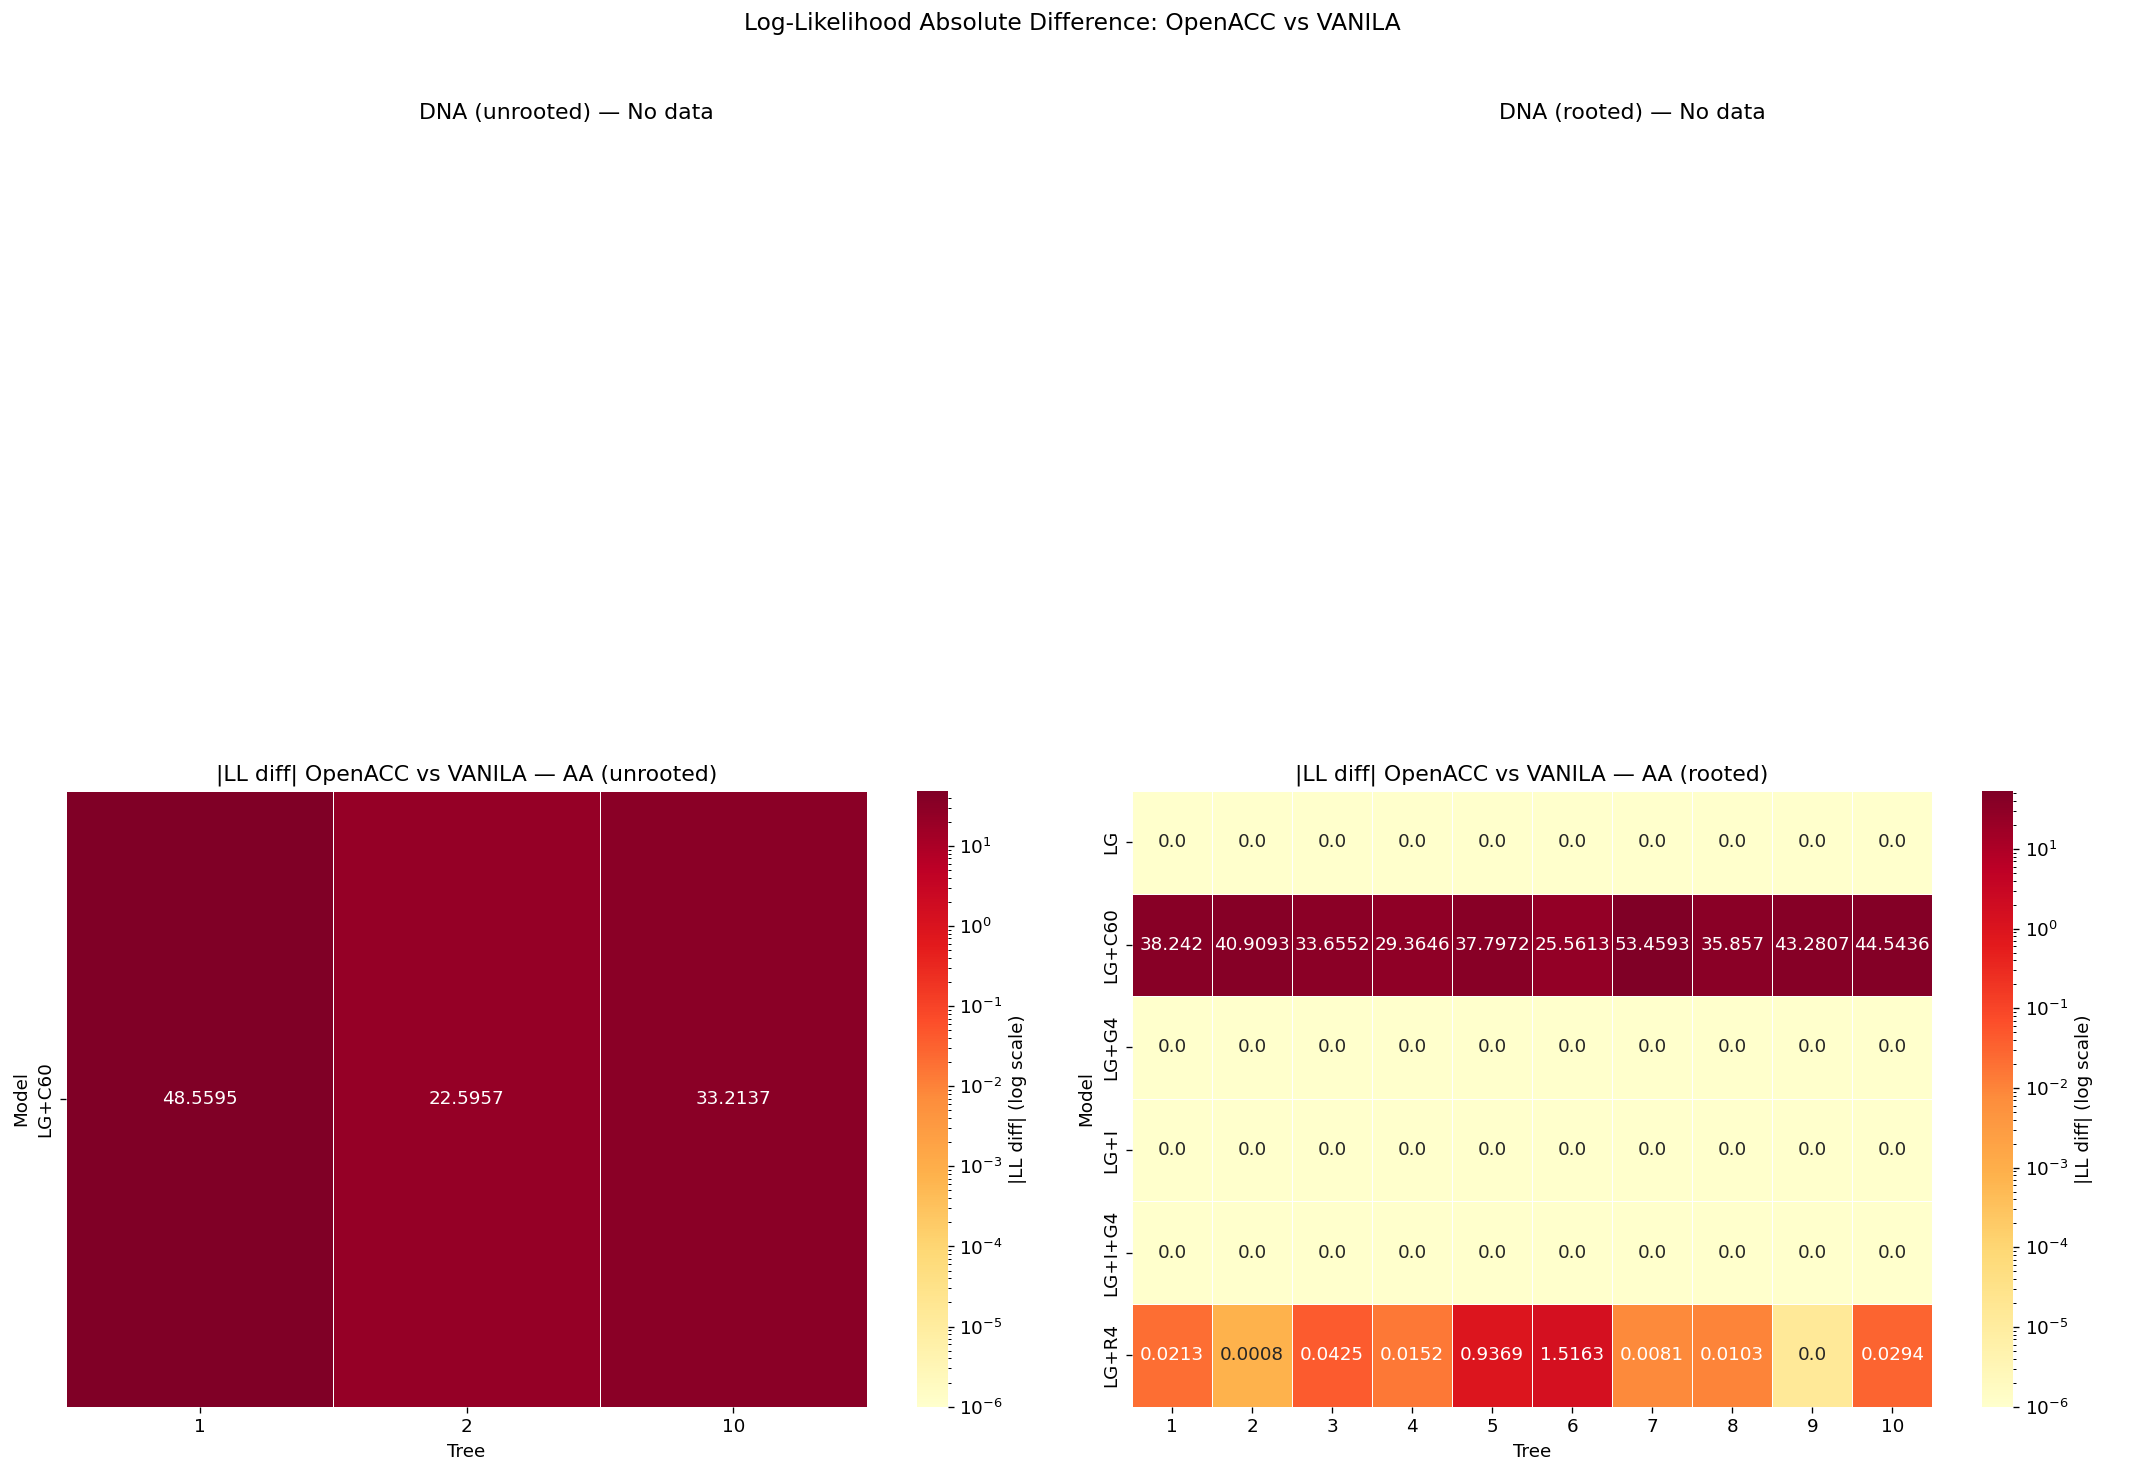

In [10]:
# LL difference heatmap per (model, tree_num)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
combos = [
    ('DNA', 'unrooted', axes[0, 0]),
    ('DNA', 'rooted',   axes[0, 1]),
    ('AA',  'unrooted', axes[1, 0]),
    ('AA',  'rooted',   axes[1, 1]),
]

for data_type, tree_type, ax in combos:
    subset = both[(both['data_type'] == data_type) & (both['tree_type'] == tree_type)]
    if len(subset) == 0:
        ax.set_title(f'{data_type} ({tree_type}) — No data')
        ax.axis('off')
        continue
    
    pivot = subset.pivot_table(index='model', columns='tree_num', 
                                values='ll_abs_diff', aggfunc='max', fill_value=0)
    pivot = pivot[sorted(pivot.columns)]
    
    # Use log scale for color if there's a big range
    max_val = pivot.max().max()
    if max_val > 1.0:
        # Log-scale coloring for large differences
        from matplotlib.colors import LogNorm
        pivot_plot = pivot.replace(0, 1e-10)  # avoid log(0)
        sns.heatmap(pivot_plot, annot=pivot.round(4).values, fmt='', cmap='YlOrRd', ax=ax,
                    linewidths=0.5, norm=LogNorm(vmin=1e-6, vmax=max_val),
                    cbar_kws={'label': '|LL diff| (log scale)'})
    else:
        sns.heatmap(pivot, annot=True, fmt='.6f', cmap='YlOrRd', ax=ax, linewidths=0.5,
                    cbar_kws={'label': '|LL diff|'})
    
    ax.set_title(f'|LL diff| OpenACC vs VANILA — {data_type} ({tree_type})')
    ax.set_xlabel('Tree')
    ax.set_ylabel('Model')

plt.suptitle('Log-Likelihood Absolute Difference: OpenACC vs VANILA', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{cwd}/ll_diff_heatmap.png', bbox_inches='tight')
plt.show()

# 5. Detailed Comparison for Each Model

In [11]:
# Per-model comparison table
for (dt, tt), group in both.groupby(['data_type', 'tree_type']):
    print(f"\n{'='*80}")
    print(f"{dt} — {tt}")
    print(f"{'='*80}")
    for model, mgroup in group.groupby('model'):
        print(f"\n--- {model} ---")
        display(mgroup[['tree_num', 'final_ll_vanila', 'final_ll_openacc', 
                         'll_diff', 'has_underflow_openacc', 'has_nan_rates_openacc',
                         'opt_rounds_vanila', 'opt_rounds_openacc']].set_index('tree_num').sort_index())


AA — rooted

--- LG ---


,final_ll_vanila,final_ll_openacc,ll_diff,has_underflow_openacc,has_nan_rates_openacc,opt_rounds_vanila,opt_rounds_openacc
tree_num,,,,,,,
1,-31.952552,-31.952552,0.0,False,False,1.0,1.0
2,-52.728259,-52.728259,0.0,False,False,1.0,1.0
3,-44.770222,-44.770222,0.0,False,False,1.0,1.0
4,-64.187202,-64.187202,0.0,False,False,1.0,1.0
5,-31.448507,-31.448507,0.0,False,False,1.0,1.0
6,-58.134412,-58.134412,0.0,False,False,1.0,1.0
7,-62.187616,-62.187616,0.0,False,False,1.0,1.0
8,-49.228005,-49.228005,0.0,False,False,1.0,1.0
9,-58.141765,-58.141765,0.0,False,False,1.0,1.0



--- LG+C60 ---


,final_ll_vanila,final_ll_openacc,ll_diff,has_underflow_openacc,has_nan_rates_openacc,opt_rounds_vanila,opt_rounds_openacc
tree_num,,,,,,,
1,-48.4110,-86.6530,-38.2420,False,False,2.0,2.0
2,-46.7955,-87.7048,-40.9093,False,False,4.0,2.0
3,-38.2773,-71.9325,-33.6552,False,False,3.0,2.0
4,-60.1356,-89.5002,-29.3646,False,False,2.0,2.0
5,-55.6071,-93.4043,-37.7972,False,False,3.0,2.0
6,-45.3339,-70.8952,-25.5613,False,False,3.0,2.0
7,-42.8248,-96.2841,-53.4593,False,False,4.0,2.0
8,-30.7472,-66.6042,-35.8570,False,False,2.0,2.0
9,-41.3954,-84.6761,-43.2807,False,False,3.0,2.0



--- LG+G4 ---


...

,final_ll_vanila,final_ll_openacc,ll_diff,has_underflow_openacc,has_nan_rates_openacc,opt_rounds_vanila,opt_rounds_openacc
tree_num,,,,,,,
1,-44.806777,-44.806777,0.0,False,False,NaN,NaN
2,-45.213150,-45.213150,0.0,False,False,NaN,NaN
3,-28.985273,-28.985273,0.0,False,False,NaN,NaN
4,-46.583952,-46.583952,0.0,False,False,NaN,NaN
5,-36.259586,-36.259586,0.0,False,False,NaN,NaN
6,-42.137416,-42.137416,0.0,False,False,NaN,NaN
7,-46.534185,-46.534185,0.0,False,False,NaN,NaN
8,-36.836102,-36.836102,0.0,False,False,NaN,NaN
9,-48.238176,-48.238176,0.0,False,False,NaN,NaN



--- LG+R4 ---


,final_ll_vanila,final_ll_openacc,ll_diff,has_underflow_openacc,has_nan_rates_openacc,opt_rounds_vanila,opt_rounds_openacc
tree_num,,,,,,,
1,-60.602739,-60.624014,-0.021275,False,False,3.0,1.0
2,-48.178228,-48.177404,0.000824,False,False,3.0,1.0
3,-55.164687,-55.207212,-0.042525,False,False,3.0,3.0
4,-50.900493,-50.885288,0.015205,False,False,3.0,1.0
5,-46.245530,-47.182449,-0.936919,False,False,3.0,1.0
6,-54.027845,-55.544163,-1.516318,False,False,6.0,1.0
7,-35.452286,-35.444209,0.008077,False,False,2.0,3.0
8,-40.563256,-40.552943,0.010313,False,False,3.0,1.0
9,-68.716488,-68.716473,0.000015,False,False,3.0,3.0



AA — unrooted

--- LG+C60 ---


,final_ll_vanila,final_ll_openacc,ll_diff,has_underflow_openacc,has_nan_rates_openacc,opt_rounds_vanila,opt_rounds_openacc
tree_num,,,,,,,
1,-40.9790,-89.5385,-48.5595,False,False,3.0,2.0
2,-43.4233,-66.0190,-22.5957,False,False,2.0,2.0
10,-34.6780,-67.8917,-33.2137,False,False,3.0,2.0


# 6. FreeRate (+R4) Parameters Comparison

In [12]:
# Compare FreeRate parameters between VANILA and OPENACC
r4_models = df[df['model'].str.contains('R4')].copy()

if len(r4_models) > 0:
    print("=" * 90)
    print("FREERATE (+R4) PARAMETER COMPARISON")
    print("=" * 90)
    
    for (dt, tt, model, tree_num), group in r4_models.groupby(['data_type', 'tree_type', 'model', 'tree_num']):
        print(f"\n--- {dt}/{tt}/{model}/tree_{tree_num} ---")
        for _, row in group.iterrows():
            backend = row['backend']
            ll = row['final_ll']
            rates_str = row.get('site_rates_str', 'N/A')
            has_nan = row.get('has_nan_rates', False)
            n_uf = row.get('n_underflow_deriv', 0)
            print(f"  {backend:10s}: LL={ll:15.4f}  rates={rates_str}")
            if has_nan:
                print(f"              *** HAS NaN RATES ***")
            if n_uf > 0:
                print(f"              *** {n_uf} derivative underflow warnings ***")
else:
    print("No +R4 models found.")

FREERATE (+R4) PARAMETER COMPARISON

--- AA/rooted/LG+R4/tree_1 ---
  VANILA    : LL=       -60.6027  rates=(0.218246,0.220824) (0.247090,0.746512) (0.273252,1.270397) (0.261412,1.607471)
  OPENACC   : LL=       -60.6240  rates=(0.240054,0.999542) (0.256578,0.999674) (0.249042,1.000330) (0.254326,1.000437)

--- AA/rooted/LG+R4/tree_2 ---
  VANILA    : LL=       -48.1782  rates=(0.203121,0.924648) (0.257516,1.003007) (0.279098,1.022222) (0.260264,1.032003)
  OPENACC   : LL=       -48.1774  rates=(0.256666,0.999830) (0.248923,0.999939) (0.263262,1.000050) (0.231149,1.000198)

--- AA/rooted/LG+R4/tree_3 ---
  VANILA    : LL=       -55.1647  rates=(0.223300,0.162849) (0.239937,0.800798) (0.273607,1.321813) (0.263156,1.557392)
  OPENACC   : LL=       -55.2072  rates=(0.248467,0.999706) (0.241538,0.999810) (0.256410,1.000209) (0.253584,1.000257)

--- AA/rooted/LG+R4/tree_4 ---
  VANILA    : LL=       -50.9005  rates=(0.207188,0.350615) (0.251530,0.982904) (0.276167,1.217071) (0.265115,1.2975

# 7. Timing Comparison

In [13]:
# Opt time and wallclock comparison
print("=" * 90)
print("TIMING SUMMARY (seconds)")
print("=" * 90)

timing = df.groupby(['data_type', 'tree_type', 'model', 'backend']).agg(
    mean_opt=('opt_time', 'mean'),
    mean_wc=('wallclock_time', 'mean'),
    mean_rounds=('opt_rounds', 'mean'),
).round(4)
display(timing)

TIMING SUMMARY (seconds)


mean_opt  mean_wc  mean_rounds
data_type tree_type model   backend                                
AA        rooted    LG      OPENACC    0.0181   0.0437       1.0000
                            VANILA     0.0008   0.0092       1.0000
                    LG+C60  OPENACC    0.6118   0.7980       2.0000
                            VANILA     0.2033   0.3595       2.9000
                    LG+G4   OPENACC    0.0579   0.0815       2.5000
                            VANILA     0.0055   0.0199       2.5000
                    LG+I    OPENACC    0.0382   0.0715       2.5000
                            VANILA     0.0042   0.0214       2.5000
                    LG+I+G4 OPENACC       NaN   0.8149          NaN
                            VANILA        NaN   0.0979          NaN
                    LG+R4   OPENACC    0.0652   0.0905       1.6000
                            VANILA     0.0248   0.0334       3.1000
          unrooted  LG+C60  OPENACC    0.6881   0.9080       2.0000
                            VANILA     0.2358   0.3783       2.6667

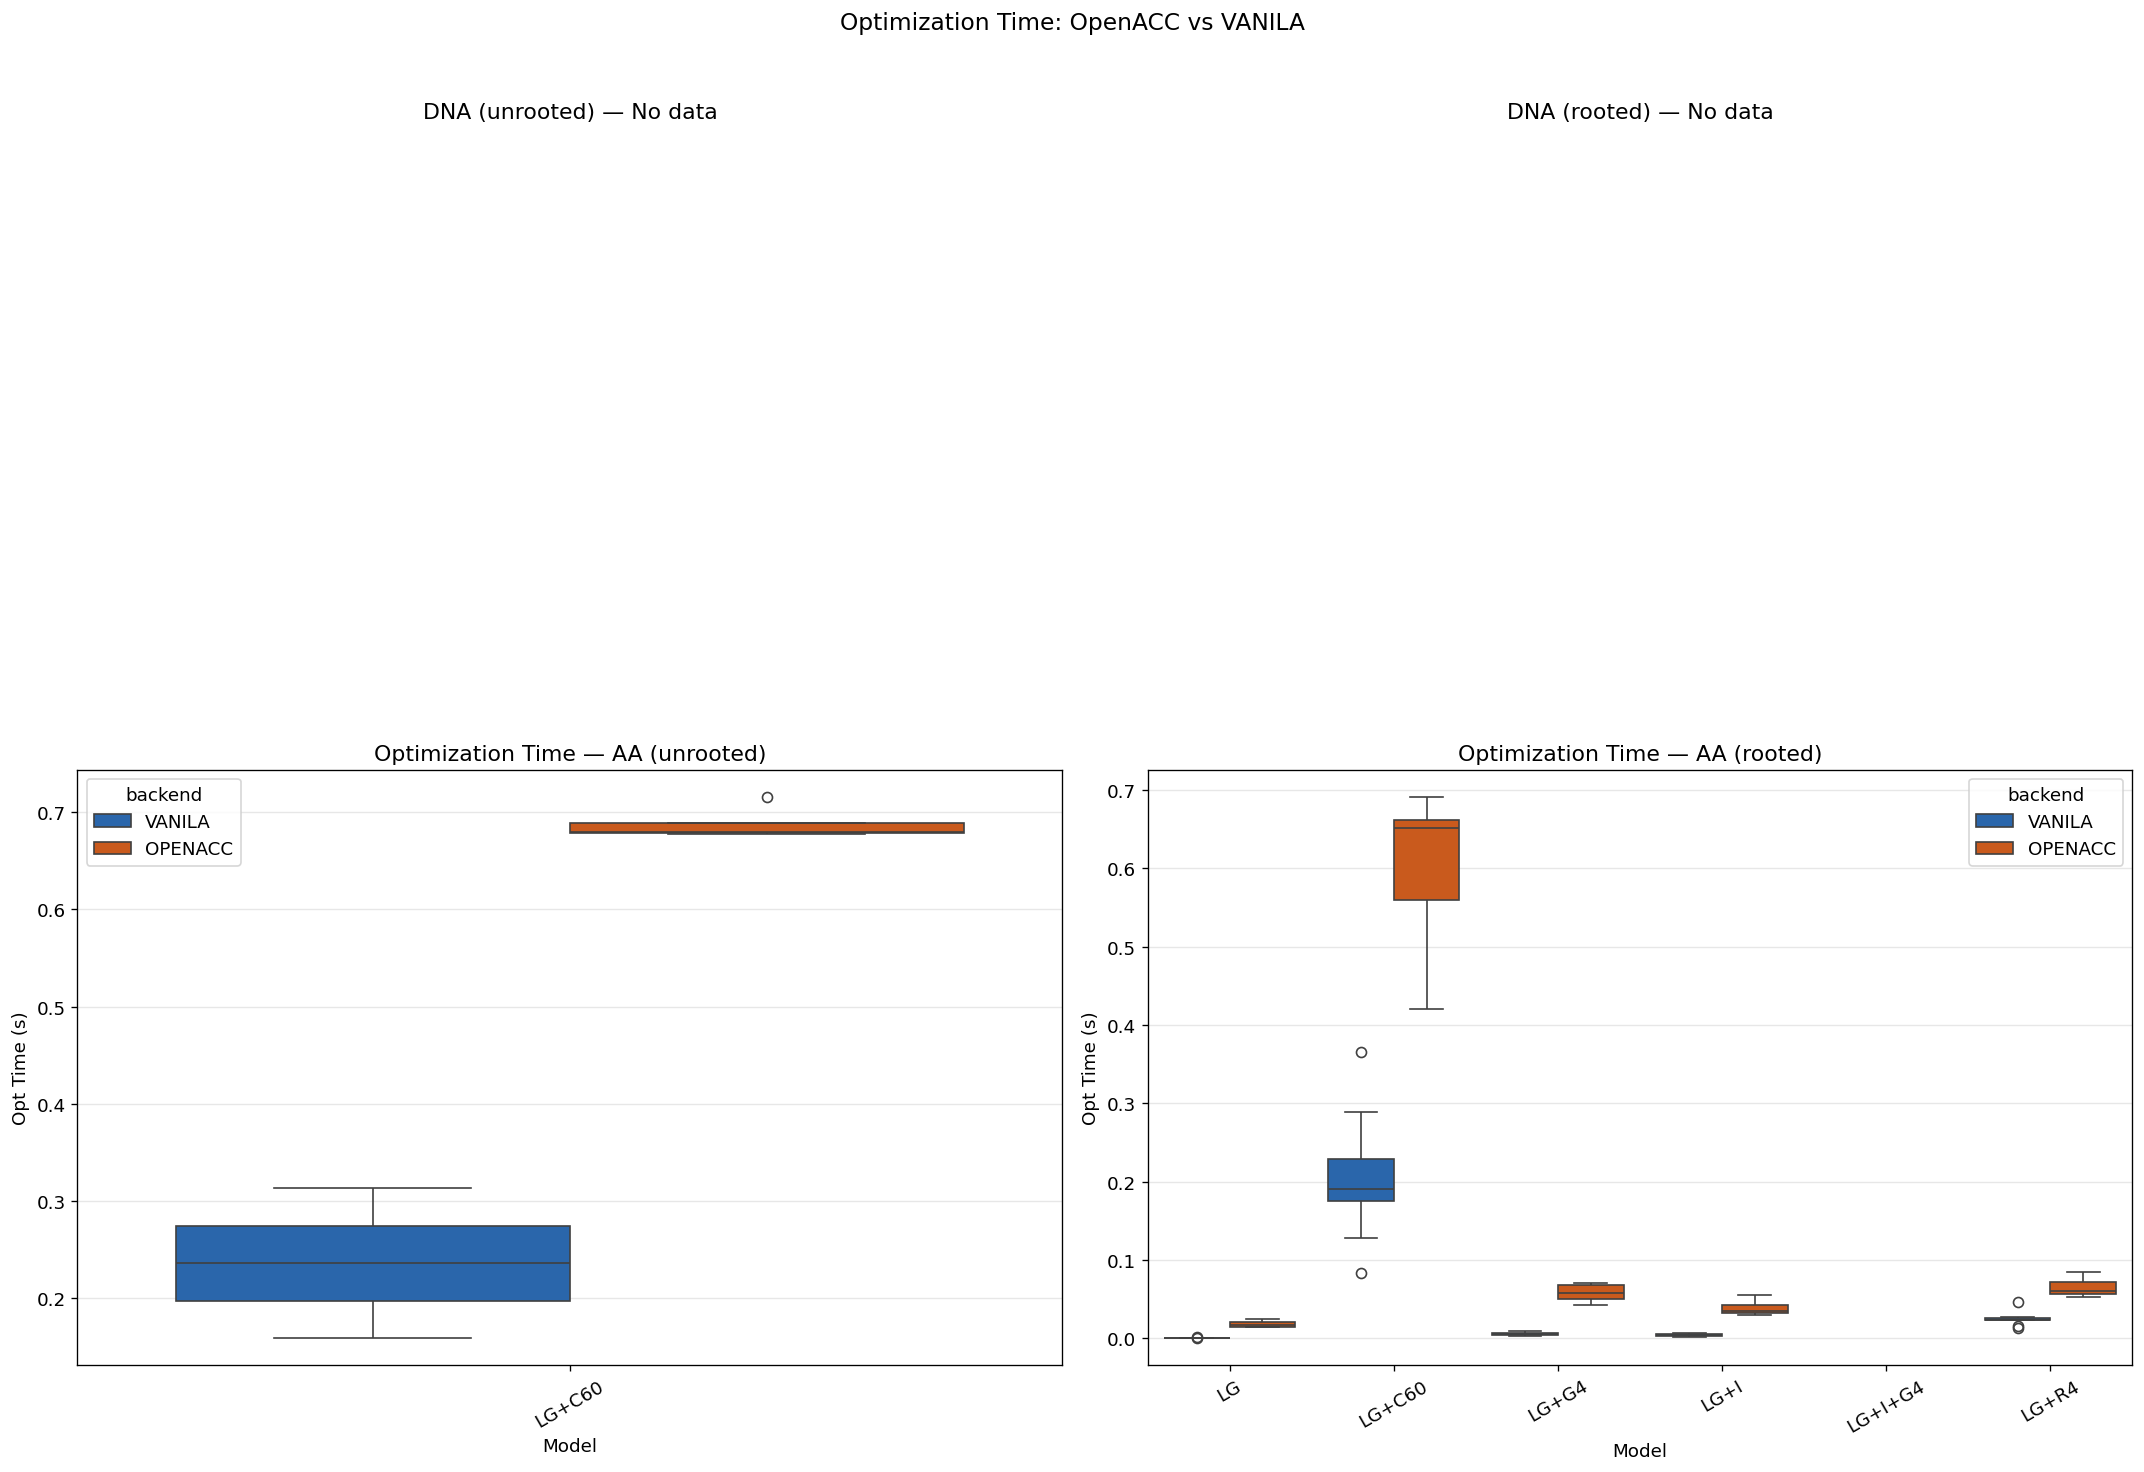

In [14]:
# Boxplot: optimization time by model, colored by backend
BACKEND_PALETTE = {'VANILA': '#1565C0', 'OPENACC': '#E65100'}
BACKEND_ORDER = ['VANILA', 'OPENACC']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
combos = [
    ('DNA', 'unrooted', axes[0, 0]),
    ('DNA', 'rooted',   axes[0, 1]),
    ('AA',  'unrooted', axes[1, 0]),
    ('AA',  'rooted',   axes[1, 1]),
]

for data_type, tree_type, ax in combos:
    subset = df[(df['data_type'] == data_type) & (df['tree_type'] == tree_type)]
    if len(subset) == 0:
        ax.set_title(f'{data_type} ({tree_type}) — No data')
        ax.axis('off')
        continue
    
    present = [b for b in BACKEND_ORDER if b in subset['backend'].unique()]
    model_order = sorted(subset['model'].unique())
    
    sns.boxplot(data=subset, x='model', y='opt_time', hue='backend',
                hue_order=present, palette=BACKEND_PALETTE, ax=ax, order=model_order)
    ax.set_title(f'Optimization Time — {data_type} ({tree_type})')
    ax.set_xlabel('Model')
    ax.set_ylabel('Opt Time (s)')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Optimization Time: OpenACC vs VANILA', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{cwd}/opt_time_comparison.png', bbox_inches='tight')
plt.show()

# 8. Model Correctness Summary

In [15]:
# Final correctness matrix: per model, is OpenACC correct?
print("=" * 90)
print("MODEL CORRECTNESS MATRIX — OpenACC vs VANILA")
print("=" * 90)
print("Criteria: |LL diff| < 0.01 AND no NaN rates AND no underflow warnings")
print()

correctness_rows = []

for (dt, tt, model), group in both.groupby(['data_type', 'tree_type', 'model']):
    n_total = len(group)
    n_ll_match = (group['ll_abs_diff'] < 0.01).sum()
    n_ll_close = (group['ll_abs_diff'] < 1.0).sum()
    n_no_underflow = (~group['has_underflow_openacc']).sum()
    n_no_nan = (~group['has_nan_rates_openacc']).sum()
    max_diff = group['ll_abs_diff'].max()
    mean_diff = group['ll_diff'].mean()
    
    all_correct = (n_ll_match == n_total) and (n_no_underflow == n_total) and (n_no_nan == n_total)
    
    correctness_rows.append({
        'data_type': dt,
        'tree_type': tt,
        'model': model,
        'n_trees': n_total,
        'n_ll_exact (<0.01)': n_ll_match,
        'n_ll_close (<1.0)': n_ll_close,
        'max |LL diff|': round(max_diff, 6),
        'mean LL diff': round(mean_diff, 6),
        'n_no_underflow': n_no_underflow,
        'n_no_nan_rates': n_no_nan,
        'STATUS': '✅ PASS' if all_correct else '❌ FAIL',
    })

correctness_df = pd.DataFrame(correctness_rows)
display(correctness_df.set_index(['data_type', 'tree_type', 'model']))

MODEL CORRECTNESS MATRIX — OpenACC vs VANILA
Criteria: |LL diff| < 0.01 AND no NaN rates AND no underflow warnings



n_trees  n_ll_exact (<0.01)  n_ll_close (<1.0)  \
data_type tree_type model                                                     
AA        rooted    LG            10                  10                 10   
                    LG+C60        10                   0                  0   
                    LG+G4         10                  10                 10   
                    LG+I          10                  10                 10   
                    LG+I+G4       10                  10                 10   
                    LG+R4         10                   3                  9   
          unrooted  LG+C60         3                   0                  0   

                             max |LL diff|  mean LL diff  n_no_underflow  \
data_type tree_type model                                                  
AA        rooted    LG            0.000000      0.000000              10   
                    LG+C60       53.459300    -38.267020              10   
                    LG+G4         0.000000      0.000000              10   
                    LG+I          0.000000      0.000000              10   
                    LG+I+G4       0.000000      0.000000              10   
                    LG+R4         1.516318     -0.251201              10   
          unrooted  LG+C60       48.559500    -34.789633               3   

                             n_no_nan_rates  STATUS  
data_type tree_type model                            
AA        rooted    LG                   10  ✅ PASS  
                    LG+C60               10  ❌ FAIL  
                    LG+G4                10  ✅ PASS  
                    LG+I                 10  ✅ PASS  
                    LG+I+G4              10  ✅ PASS  
                    LG+R4                10  ❌ FAIL  
          unrooted  LG+C60                3  ❌ FAIL

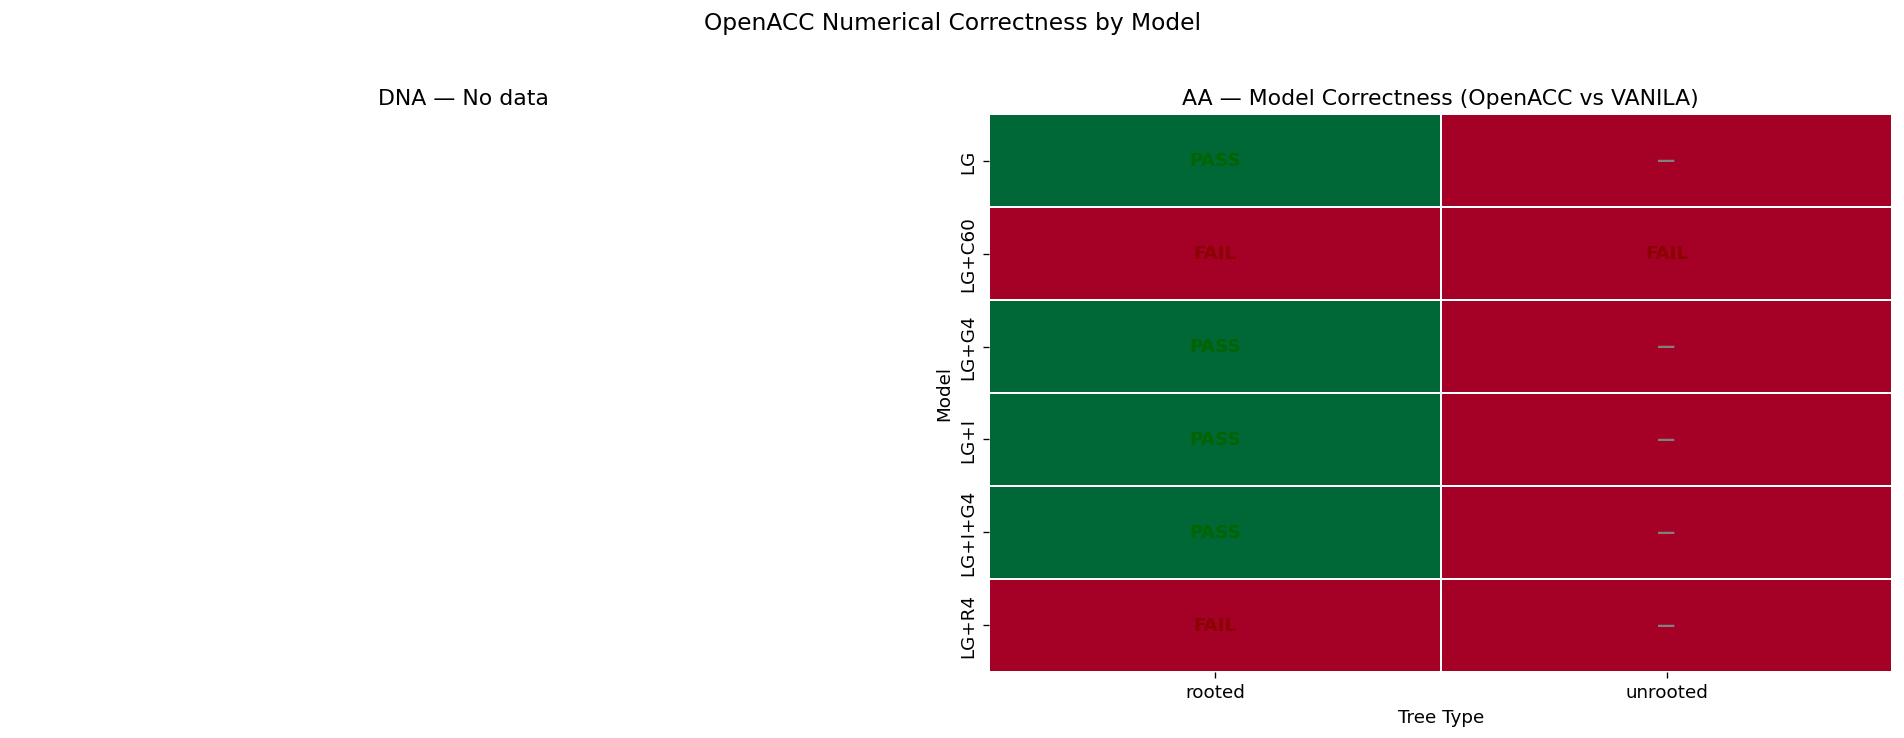

In [16]:
# Visual correctness heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (dt, label) in enumerate([('DNA', 'DNA'), ('AA', 'AA')]):
    ax = axes[i]
    subset = correctness_df[correctness_df['data_type'] == dt].copy()
    if len(subset) == 0:
        ax.set_title(f'{label} — No data')
        ax.axis('off')
        continue
    
    # Create status matrix: 1=PASS, 0=FAIL
    subset['status_num'] = (subset['STATUS'] == '✅ PASS').astype(int)
    pivot = subset.pivot_table(index='model', columns='tree_type', values='status_num', fill_value=-1).astype(int)
    
    cmap = plt.cm.RdYlGn
    # Don't annotate with numbers — we'll overlay emoji text
    sns.heatmap(pivot, annot=False, cmap=cmap, vmin=0, vmax=1,
                ax=ax, linewidths=1, cbar=False,
                xticklabels=True, yticklabels=True)
    
    # Annotate with PASS/FAIL text
    for y_idx, model in enumerate(pivot.index):
        for x_idx, tt in enumerate(pivot.columns):
            val = pivot.loc[model, tt]
            text = 'PASS' if val == 1 else 'FAIL' if val == 0 else '—'
            color = 'darkgreen' if val == 1 else 'darkred' if val == 0 else 'gray'
            ax.text(x_idx + 0.5, y_idx + 0.5, text, ha='center', va='center', 
                    fontsize=11, fontweight='bold', color=color)
    
    ax.set_title(f'{label} — Model Correctness (OpenACC vs VANILA)')
    ax.set_xlabel('Tree Type')
    ax.set_ylabel('Model')

plt.suptitle('OpenACC Numerical Correctness by Model', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{cwd}/correctness_matrix.png', bbox_inches='tight')
plt.show()

# 9. Scatter: VANILA LL vs OpenACC LL

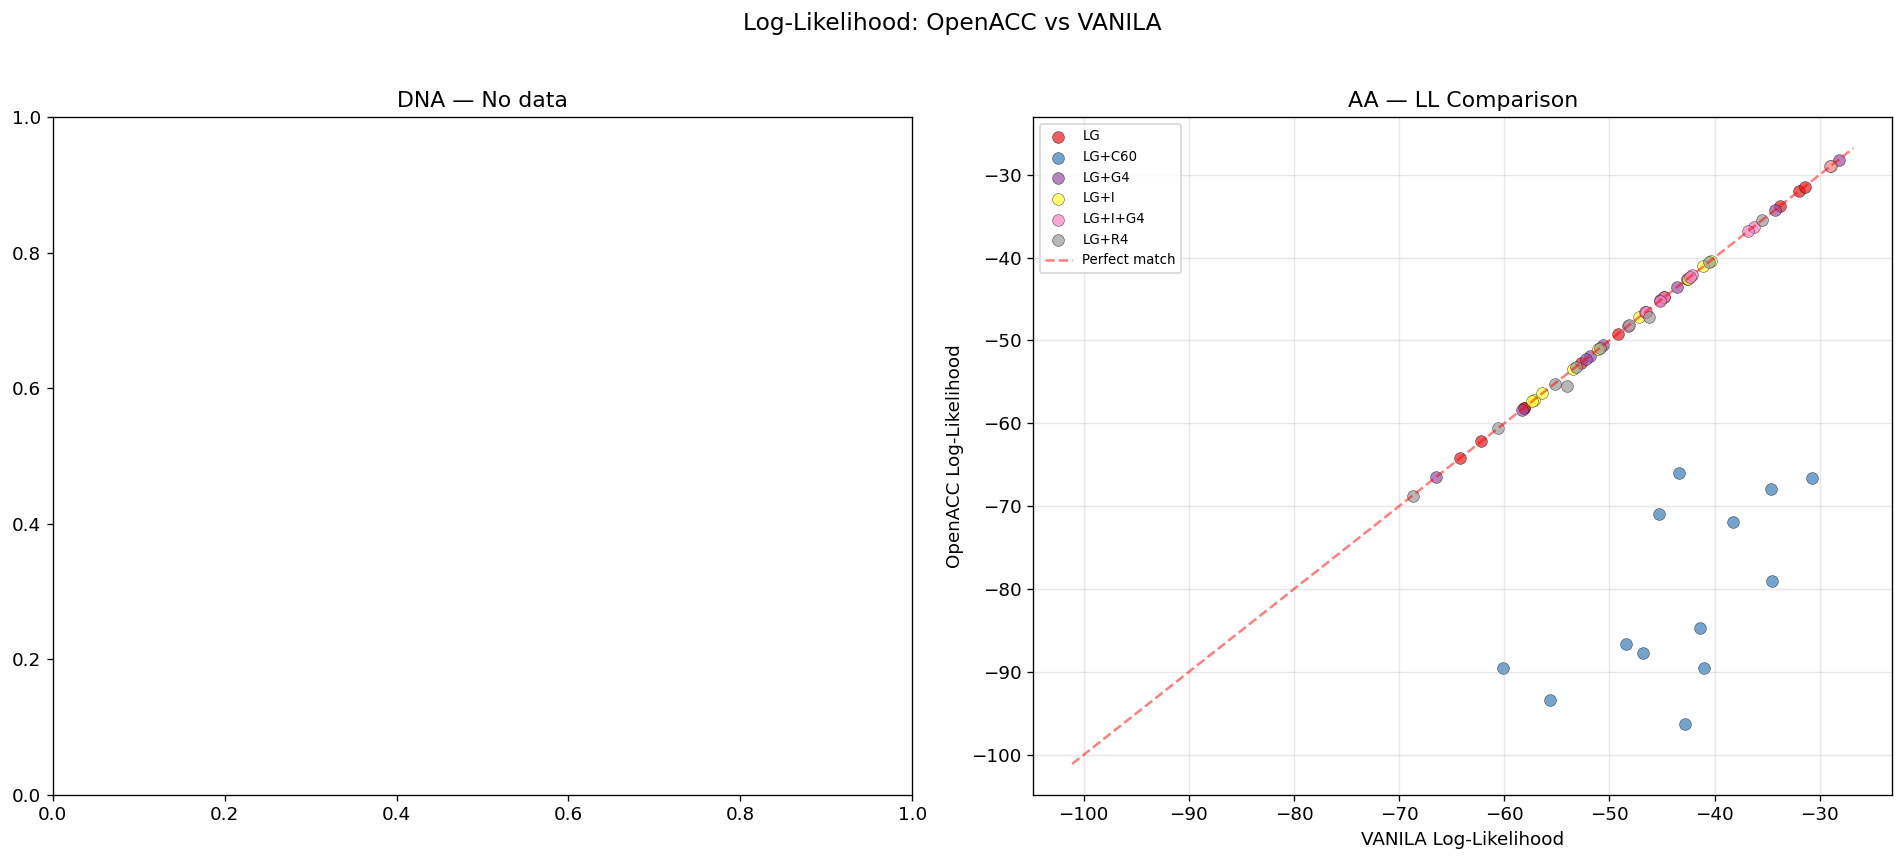

In [17]:
# Scatter plot: VANILA LL vs OPENACC LL, colored by model
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, dt in enumerate(['DNA', 'AA']):
    ax = axes[i]
    subset = both[both['data_type'] == dt]
    if len(subset) == 0:
        ax.set_title(f'{dt} — No data')
        continue
    
    models = sorted(subset['model'].unique())
    colors = plt.cm.Set1(np.linspace(0, 1, len(models)))
    
    for model, color in zip(models, colors):
        msub = subset[subset['model'] == model]
        ax.scatter(msub['final_ll_vanila'], msub['final_ll_openacc'], 
                   label=model, alpha=0.7, s=50, color=color, edgecolors='black', linewidth=0.3)
    
    # Perfect agreement line
    all_lls = pd.concat([subset['final_ll_vanila'], subset['final_ll_openacc']])
    lim_min, lim_max = all_lls.min() * 1.05, all_lls.max() * 0.95
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', alpha=0.5, label='Perfect match')
    
    ax.set_xlabel('VANILA Log-Likelihood')
    ax.set_ylabel('OpenACC Log-Likelihood')
    ax.set_title(f'{dt} — LL Comparison')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Log-Likelihood: OpenACC vs VANILA', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{cwd}/ll_scatter.png', bbox_inches='tight')
plt.show()

# 10. Optimization Rounds Comparison

In [18]:
# Compare number of optimization rounds
print("=" * 90)
print("OPTIMIZATION ROUNDS: OpenACC vs VANILA")
print("=" * 90)

both['rounds_diff'] = both['opt_rounds_openacc'] - both['opt_rounds_vanila']

rounds_summary = both.groupby(['data_type', 'tree_type', 'model']).agg(
    mean_rounds_vanila=('opt_rounds_vanila', 'mean'),
    mean_rounds_openacc=('opt_rounds_openacc', 'mean'),
    mean_rounds_diff=('rounds_diff', 'mean'),
    max_rounds_diff=('rounds_diff', lambda x: x.abs().max()),
).round(1)
display(rounds_summary)

OPTIMIZATION ROUNDS: OpenACC vs VANILA


mean_rounds_vanila  mean_rounds_openacc  \
data_type tree_type model                                              
AA        rooted    LG                      1.0                  1.0   
                    LG+C60                  2.9                  2.0   
                    LG+G4                   2.5                  2.5   
                    LG+I                    2.5                  2.5   
                    LG+I+G4                 NaN                  NaN   
                    LG+R4                   3.1                  1.6   
          unrooted  LG+C60                  2.7                  2.0   

                             mean_rounds_diff  max_rounds_diff  
data_type tree_type model                                       
AA        rooted    LG                    0.0              0.0  
                    LG+C60               -0.9              2.0  
                    LG+G4                 0.0              0.0  
                    LG+I                  0.0              0.0  
                    LG+I+G4               NaN              NaN  
                    LG+R4                -1.5              5.0  
          unrooted  LG+C60               -0.7              1.0

# 11. LG+C60 Special Analysis (Mixture Model)

In [19]:
# Check LG+C60 results specifically
c60 = df[df['model'] == 'LG+C60'].copy()
if len(c60) > 0:
    print(f"LG+C60 records: {len(c60)}")
    print(f"\nBreakdown:")
    display(c60.groupby(['tree_type', 'backend']).agg(
        n=('final_ll', 'count'),
        mean_ll=('final_ll', 'mean'),
        mean_opt=('opt_time', 'mean'),
        n_underflow=('has_underflow', 'sum'),
    ).round(4))
    
    # Compare if both backends exist
    c60_both = c60.pivot_table(index=['tree_type', 'tree_num'], columns='backend', 
                                values='final_ll')
    if 'VANILA' in c60_both.columns and 'OPENACC' in c60_both.columns:
        c60_both['diff'] = c60_both['OPENACC'] - c60_both['VANILA']
        print(f"\nLL differences (C60):")
        display(c60_both)
else:
    print("No LG+C60 results found.")

LG+C60 records: 27

Breakdown:


n  mean_ll  mean_opt  n_underflow
tree_type backend                                    
rooted    OPENACC  10 -82.6728    0.6118            0
          VANILA   10 -44.4057    0.2033            0
unrooted  OPENACC   4 -77.2651    0.6881            0
          VANILA    3 -39.6934    0.2358            0


LL differences (C60):


backend             OPENACC   VANILA     diff
tree_type tree_num                           
rooted    1        -86.6530 -48.4110 -38.2420
          2        -87.7048 -46.7955 -40.9093
          3        -71.9325 -38.2773 -33.6552
          4        -89.5002 -60.1356 -29.3646
          5        -93.4043 -55.6071 -37.7972
          6        -70.8952 -45.3339 -25.5613
          7        -96.2841 -42.8248 -53.4593
          8        -66.6042 -30.7472 -35.8570
          9        -84.6761 -41.3954 -43.2807
          10       -79.0731 -34.5295 -44.5436
unrooted  1        -89.5385 -40.9790 -48.5595
          2        -66.0190 -43.4233 -22.5957
          3        -85.6111      NaN      NaN
          10       -67.8917 -34.6780 -33.2137

# 12. Final Summary Table

In [20]:
print("=" * 90)
print("FINAL SUMMARY: OpenACC Correctness for Complex Models")
print("=" * 90)
print()

# All models tested
all_models = df.groupby(['data_type', 'model', 'backend']).size().unstack(fill_value=0)
print("All models tested (record counts):")
display(all_models)

# Correctness summary
print("\n" + "-" * 90)
print("CORRECTNESS RESULTS:")
print("-" * 90)

n_pass = (correctness_df['STATUS'] == '✅ PASS').sum()
n_fail = (correctness_df['STATUS'] == '❌ FAIL').sum()
n_total = len(correctness_df)

print(f"\n  Total model×tree_type combinations tested: {n_total}")
print(f"  PASS (exact match, no warnings):           {n_pass}")
print(f"  FAIL (LL mismatch or underflow):            {n_fail}")
print(f"  Pass rate: {100*n_pass/n_total:.1f}%")

if n_fail > 0:
    print(f"\n  FAILING models:")
    for _, row in correctness_df[correctness_df['STATUS'] == '❌ FAIL'].iterrows():
        print(f"    {row['data_type']}/{row['tree_type']}/{row['model']}: "
              f"max|diff|={row['max |LL diff|']:.6f}, "
              f"underflow={row['n_trees']-row['n_no_underflow']}/{row['n_trees']}, "
              f"nan_rates={row['n_trees']-row['n_no_nan_rates']}/{row['n_trees']}")

print(f"\n  PASSING models:")
for _, row in correctness_df[correctness_df['STATUS'] == '✅ PASS'].iterrows():
    print(f"    {row['data_type']}/{row['tree_type']}/{row['model']}: "
          f"max|diff|={row['max |LL diff|']:.6f}")

FINAL SUMMARY: OpenACC Correctness for Complex Models

All models tested (record counts):


backend            OPENACC  VANILA
data_type model                   
AA        LG            10      10
          LG+C60        14      13
          LG+G4         10      10
          LG+I          10      10
          LG+I+G4       10      10
          LG+R4         10      10


------------------------------------------------------------------------------------------
CORRECTNESS RESULTS:
------------------------------------------------------------------------------------------

  Total model×tree_type combinations tested: 7
  PASS (exact match, no warnings):           4
  FAIL (LL mismatch or underflow):            3
  Pass rate: 57.1%

  FAILING models:
    AA/rooted/LG+C60: max|diff|=53.459300, underflow=0/10, nan_rates=0/10
    AA/rooted/LG+R4: max|diff|=1.516318, underflow=0/10, nan_rates=0/10
    AA/unrooted/LG+C60: max|diff|=48.559500, underflow=0/3, nan_rates=0/3

  PASSING models:
    AA/rooted/LG: max|diff|=0.000000
    AA/rooted/LG+G4: max|diff|=0.000000
    AA/rooted/LG+I: max|diff|=0.000000
    AA/rooted/LG+I+G4: max|diff|=0.000000


In [21]:
# Save correctness dataframe to CSV for reference
correctness_df.to_csv(f'{cwd}/correctness_summary.csv', index=False)
print(f"Saved correctness summary to {cwd}/correctness_summary.csv")

# Save full merged comparison to CSV
both.to_csv(f'{cwd}/ll_comparison.csv', index=False)
print(f"Saved LL comparison to {cwd}/ll_comparison.csv")

Saved correctness summary to /Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_03_19_complexdata_bugfixes_v4/correctness_summary.csv
Saved LL comparison to /Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_03_19_complexdata_bugfixes_v4/ll_comparison.csv
